# 📘 Notebook Pemahaman Data (Rekayasa Fitur) — v3

Notebook ini adalah materi pendamping untuk **Mata Kuliah Rekayasa Fitur** (Pertemuan 2).

## 🎯 Tujuan
- Memahami karakteristik data
- Mengidentifikasi masalah dalam data
- Menentukan implikasi terhadap feature engineering

---

**Dataset yang digunakan:** `dataset_harga_rumah.csv` — Data harga rumah dengan fitur numerik dan kategorikal.

---
# 0. Setup Awal

Import semua library yang dibutuhkan untuk eksplorasi dan visualisasi data.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# Pengaturan tampilan
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print('✅ Semua library berhasil dimuat!')

✅ Semua library berhasil dimuat!


---
# 1. Load Data

Gunakan dataset tabular sederhana. Format CSV (Comma-Separated Values) adalah format yang sangat umum digunakan karena ringan dan mudah dibaca.

In [2]:
# Memuat data dari file CSV
df = pd.read_csv('dataset_harga_rumah.csv')

# Menampilkan 5 baris pertama
print('📋 5 Data Teratas:')
display(df.head())

📋 5 Data Teratas:


,ID,Luas Tanah (m²),Luas Bangunan (m²),Jumlah Kamar Tidur,Jumlah Kamar Mandi,Usia Bangunan (tahun),Jarak ke Pusat Kota (km),Indeks Kualitas Lingkungan (1-10),Jenis Properti,Gaya Arsitektur,Kondisi Bangunan,Harga Jual (Rp)
0,1,150,120,3,2,10,5,8,Rumah Tapak,Minimalis,Baik,1500000000
1,2,200,180,4,3,5,3,9,Rumah Tapak,Modern,Sangat Baik,2800000000
2,3,75,60,2,1,20,8,6,Apartemen,Klasik,Cukup,800000000
3,4,100,80,3,2,15,6,7,Rumah Tapak,Mediterania,Renovasi,1200000000
4,5,50,40,1,1,30,10,5,Apartemen,Kontemporer,Perlu Perbaikan,500000000


In [3]:
# Menampilkan 5 data terakhir
print('📋 5 Data Terbawah:')
display(df.tail())

📋 5 Data Terbawah:


,ID,Luas Tanah (m²),Luas Bangunan (m²),Jumlah Kamar Tidur,Jumlah Kamar Mandi,Usia Bangunan (tahun),Jarak ke Pusat Kota (km),Indeks Kualitas Lingkungan (1-10),Jenis Properti,Gaya Arsitektur,Kondisi Bangunan,Harga Jual (Rp)
15,16,130,100,3,2,9,4,8,Rumah Tapak,Modern,Baik,1400000000
16,17,240,210,5,3,1,1,10,Rumah Tapak,Minimalis,Sangat Baik,3800000000
17,18,105,85,3,1,26,9,5,Rumah Tapak,Klasik,Cukup,1000000000
18,19,170,140,4,2,7,3,9,Rumah Tapak,Mediterania,Baik,2400000000
19,20,70,60,2,1,19,7,6,Apartemen,Kontemporer,Renovasi,700000000


---
# 2. Struktur Data (First Contact)

Langkah pertama dalam memahami data adalah memeriksa struktur dasarnya:
- Berapa jumlah baris dan kolom?
- Apa saja tipe data?
- Mana target variable?

In [4]:
# Melihat dimensi data (baris, kolom)
print(f'📐 Dimensi Data: {df.shape[0]} baris × {df.shape[1]} kolom')
print()

📐 Dimensi Data: 20 baris × 12 kolom



In [5]:
# Informasi lengkap tentang DataFrame
print('📊 Informasi Detail Dataset:')
df.info()

📊 Informasi Detail Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 12 columns):
 #   Column                             Non-Null Count  Dtype 
---  ------                             --------------  ----- 
 0   ID                                 20 non-null     int64 
 1   Luas Tanah (m²)                    20 non-null     int64 
 2   Luas Bangunan (m²)                 20 non-null     int64 
 3   Jumlah Kamar Tidur                 20 non-null     int64 
 4   Jumlah Kamar Mandi                 20 non-null     int64 
 5   Usia Bangunan (tahun)              20 non-null     int64 
 6   Jarak ke Pusat Kota (km)           20 non-null     int64 
 7   Indeks Kualitas Lingkungan (1-10)  20 non-null     int64 
 8   Jenis Properti                     20 non-null     object
 9   Gaya Arsitektur                    20 non-null     object
 10  Kondisi Bangunan                   20 non-null     object
 11  Harga Jual (Rp)                    20 non-nul

In [6]:
# Ringkasan statistik deskriptif untuk kolom numerik
print('📈 Statistik Deskriptif (Numerik):')
display(df.describe())

📈 Statistik Deskriptif (Numerik):


,ID,Luas Tanah (m²),Luas Bangunan (m²),Jumlah Kamar Tidur,Jumlah Kamar Mandi,Usia Bangunan (tahun),Jarak ke Pusat Kota (km),Indeks Kualitas Lingkungan (1-10),Harga Jual (Rp)
count,20.00000,20.000000,20.000000,20.000000,20.000000,20.000000,20.00000,20.000000,2.000000e+01
mean,10.50000,130.500000,108.250000,2.950000,1.850000,14.100000,5.60000,7.350000,1.672500e+09
std,5.91608,61.513798,55.494784,1.145931,0.875094,9.095401,2.81724,1.694418,1.104712e+09
min,1.00000,50.000000,40.000000,1.000000,1.000000,1.000000,1.00000,5.000000,5.000000e+08
25%,5.75000,82.500000,63.750000,2.000000,1.000000,6.750000,3.00000,6.000000,8.375000e+08
50%,10.50000,115.000000,90.000000,3.000000,2.000000,13.500000,5.50000,7.500000,1.325000e+09
75%,15.25000,172.500000,142.500000,4.000000,2.000000,20.500000,8.00000,9.000000,2.425000e+09
max,20.00000,250.000000,220.000000,5.000000,4.000000,30.000000,10.00000,10.000000,4.000000e+09


In [7]:
# Ringkasan statistik deskriptif untuk kolom kategorikal
print('📈 Statistik Deskriptif (Kategorikal):')
display(df.describe(include='object'))

📈 Statistik Deskriptif (Kategorikal):


,Jenis Properti,Gaya Arsitektur,Kondisi Bangunan
count,20,20,20
unique,2,5,5
top,Rumah Tapak,Minimalis,Baik
freq,14,5,6


### ✏️ Analisis:
- Dataset memiliki **20 baris** dan **12 kolom**
- **Target variable:** `Harga Jual (Rp)` — ini adalah variabel yang ingin kita prediksi
- Terdapat **9 kolom numerik** (int64) dan **3 kolom kategorikal** (object)
- Kolom `ID` adalah identifier, bukan fitur yang berguna untuk modeling

---
# 3. Tipe Data

Mengidentifikasi tipe data setiap kolom penting untuk menentukan preprocessing yang tepat.

In [8]:
# Melihat tipe data setiap kolom
print('🔍 Tipe Data Setiap Kolom:')
print(df.dtypes)
print()

🔍 Tipe Data Setiap Kolom:
ID                                    int64
Luas Tanah (m²)                       int64
Luas Bangunan (m²)                    int64
Jumlah Kamar Tidur                    int64
Jumlah Kamar Mandi                    int64
Usia Bangunan (tahun)                 int64
Jarak ke Pusat Kota (km)              int64
Indeks Kualitas Lingkungan (1-10)     int64
Jenis Properti                       object
Gaya Arsitektur                      object
Kondisi Bangunan                     object
Harga Jual (Rp)                       int64
dtype: object



In [9]:
# Memisahkan kolom numerik dan kategorikal
kolom_numerik = df.select_dtypes(include=np.number).columns.tolist()
kolom_kategorikal = df.select_dtypes(include='object').columns.tolist()

print(f'📊 Kolom Numerik ({len(kolom_numerik)}): {kolom_numerik}')
print(f'📊 Kolom Kategorikal ({len(kolom_kategorikal)}): {kolom_kategorikal}')

📊 Kolom Numerik (9): ['ID', 'Luas Tanah (m²)', 'Luas Bangunan (m²)', 'Jumlah Kamar Tidur', 'Jumlah Kamar Mandi', 'Usia Bangunan (tahun)', 'Jarak ke Pusat Kota (km)', 'Indeks Kualitas Lingkungan (1-10)', 'Harga Jual (Rp)']
📊 Kolom Kategorikal (3): ['Jenis Properti', 'Gaya Arsitektur', 'Kondisi Bangunan']


In [10]:
# Memeriksa nilai-nilai unik setiap kolom kategorikal
print('🏷️ Nilai Unik Kolom Kategorikal:')
for col in kolom_kategorikal:
    print(f'\n  {col}:')
    print(f'    Jumlah unik: {df[col].nunique()}')
    print(f'    Nilai: {df[col].unique()}')

🏷️ Nilai Unik Kolom Kategorikal:

  Jenis Properti:
    Jumlah unik: 2
    Nilai: ['Rumah Tapak' 'Apartemen']

  Gaya Arsitektur:
    Jumlah unik: 5
    Nilai: ['Minimalis' 'Modern' 'Klasik' 'Mediterania' 'Kontemporer']

  Kondisi Bangunan:
    Jumlah unik: 5
    Nilai: ['Baik' 'Sangat Baik' 'Cukup' 'Renovasi' 'Perlu Perbaikan']


### ✏️ Analisis:
- **Numerik**: Luas Tanah, Luas Bangunan, Jumlah Kamar, Usia Bangunan, Jarak, Indeks Kualitas, Harga Jual
- **Kategorikal**: Jenis Properti (2 nilai), Gaya Arsitektur (5 nilai), Kondisi Bangunan (5 nilai)
- Kolom `ID` seharusnya bukan fitur — perlu dibuang saat modeling
- Semua tipe data sudah sesuai (tidak ada tipe yang salah)

---
# 4. Missing Value Analysis

Mengecek apakah ada data yang hilang (missing values) dan polanya.

In [11]:
# Menghitung jumlah missing value per kolom
print('❓ Jumlah Missing Value per Kolom:')
missing = df.isnull().sum()
missing_persen = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Jumlah Missing': missing,
    'Persentase (%)': missing_persen.round(2)
})
display(missing_df)

❓ Jumlah Missing Value per Kolom:


,Jumlah Missing,Persentase (%)
ID,0,0.0
Luas Tanah (m²),0,0.0
Luas Bangunan (m²),0,0.0
Jumlah Kamar Tidur,0,0.0
Jumlah Kamar Mandi,0,0.0
Usia Bangunan (tahun),0,0.0
Jarak ke Pusat Kota (km),0,0.0
Indeks Kualitas Lingkungan (1-10),0,0.0
Jenis Properti,0,0.0
Gaya Arsitektur,0,0.0


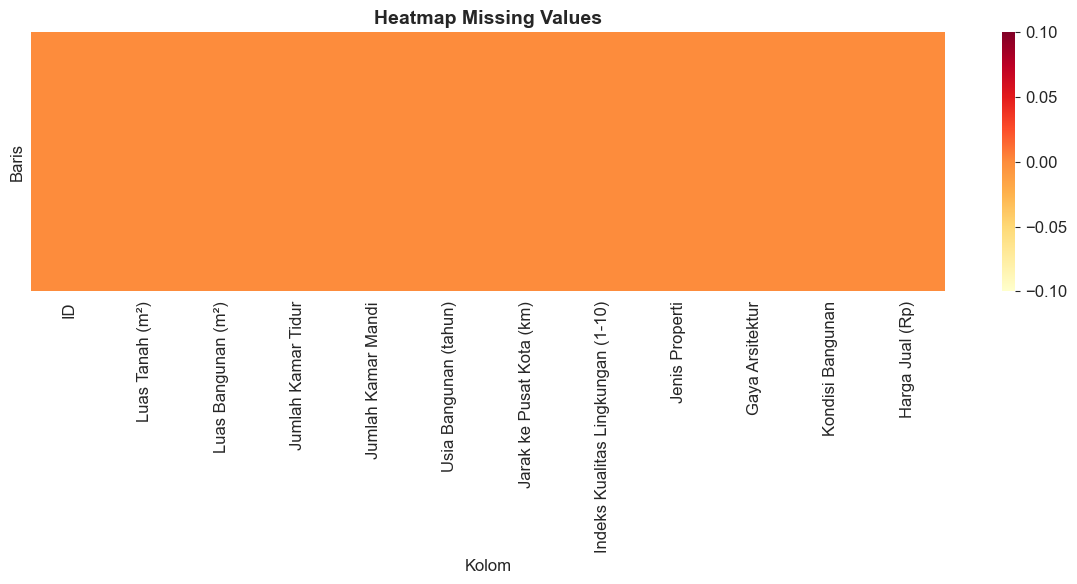

In [12]:
# Visualisasi missing value dengan heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=True, cmap='YlOrRd', yticklabels=False)
plt.title('Heatmap Missing Values', fontsize=14, fontweight='bold')
plt.xlabel('Kolom')
plt.ylabel('Baris')
plt.tight_layout()
plt.show()

### ✏️ Analisis:
- Dataset ini **tidak memiliki missing value** sama sekali
- Pada kasus nyata, missing value sering ditemui dan perlu ditangani:
  - **Jika acak**: bisa diimputasi (mean, median, mode)
  - **Jika berpolaa**: perlu investigasi lebih lanjut (mungkin ada data leakage)

---
# 5. Distribusi Data

Memahami distribusi setiap fitur numerik untuk menentukan apakah perlu transformasi.

📊 Histogram Seluruh Fitur Numerik:


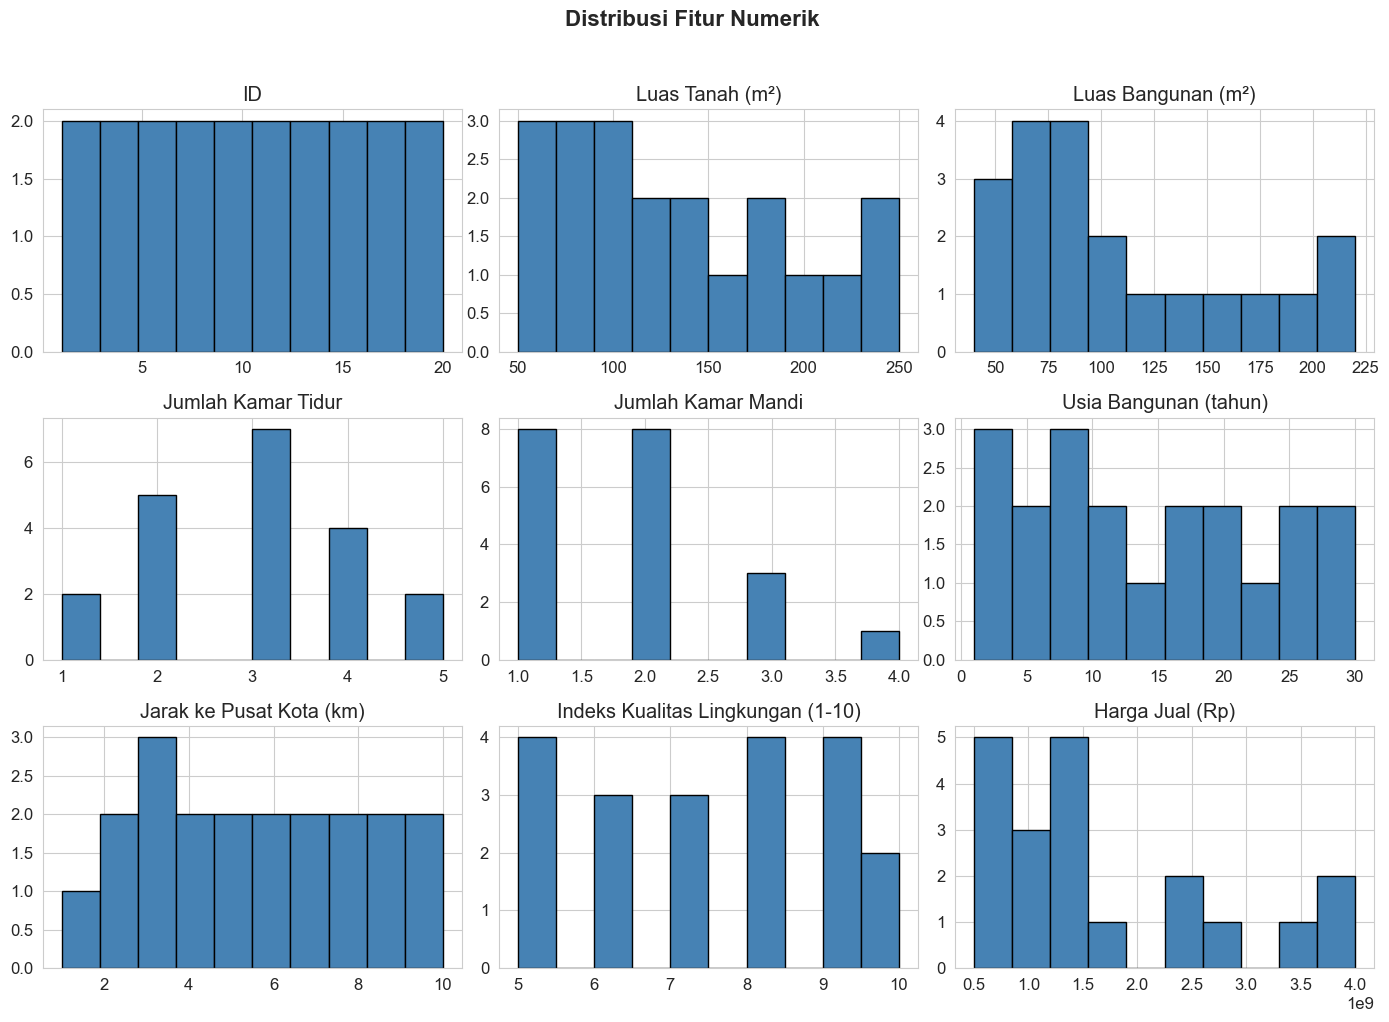

In [13]:
# Histogram untuk semua fitur numerik sekaligus
print('📊 Histogram Seluruh Fitur Numerik:')
df.hist(figsize=(14, 10), bins=10, edgecolor='black', color='steelblue')
plt.suptitle('Distribusi Fitur Numerik', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

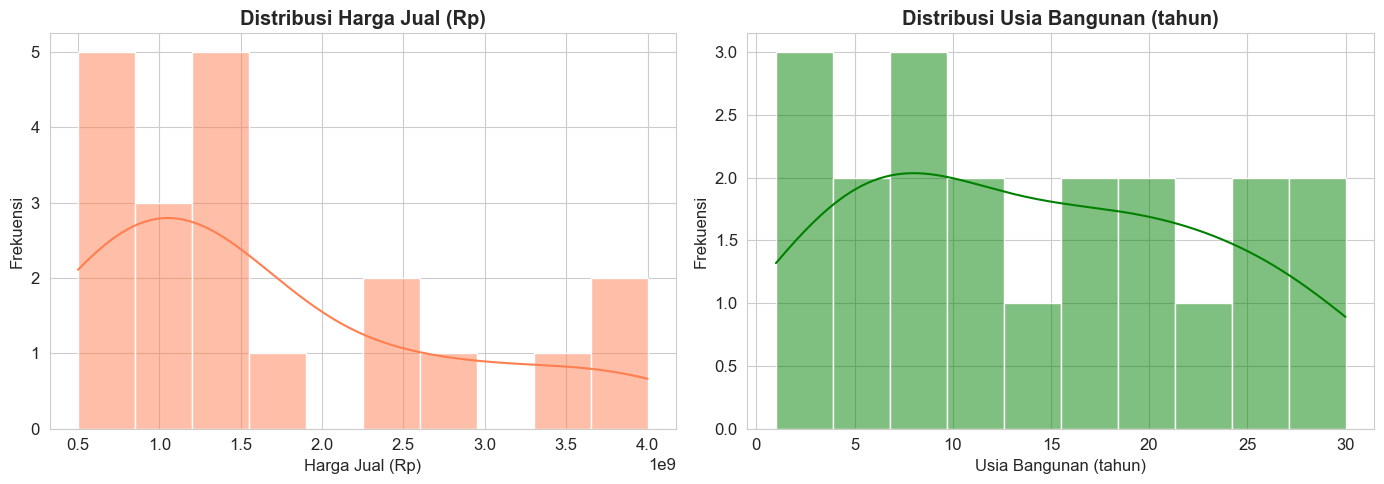

In [14]:
# Distribusi detail fitur target: Harga Jual
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram + KDE
sns.histplot(df['Harga Jual (Rp)'], kde=True, bins=10, color='coral', ax=axes[0])
axes[0].set_title('Distribusi Harga Jual (Rp)', fontweight='bold')
axes[0].set_xlabel('Harga Jual (Rp)')
axes[0].set_ylabel('Frekuensi')

# Distribusi Usia Bangunan
sns.histplot(df['Usia Bangunan (tahun)'], kde=True, bins=10, color='green', ax=axes[1])
axes[1].set_title('Distribusi Usia Bangunan (tahun)', fontweight='bold')
axes[1].set_xlabel('Usia Bangunan (tahun)')
axes[1].set_ylabel('Frekuensi')

plt.tight_layout()
plt.show()

In [15]:
# Mengecek skewness (kemiringan) distribusi
print('📐 Skewness (Kemiringan) Fitur Numerik:')
skewness = df.select_dtypes(include=np.number).skew()
for col, val in skewness.items():
    status = '✅ Normal' if abs(val) < 0.5 else ('⚠️ Cukup Skewed' if abs(val) < 1 else '🔴 Sangat Skewed')
    print(f'  {col}: {val:.3f} → {status}')

📐 Skewness (Kemiringan) Fitur Numerik:
  ID: 0.000 → ✅ Normal
  Luas Tanah (m²): 0.629 → ⚠️ Cukup Skewed
  Luas Bangunan (m²): 0.820 → ⚠️ Cukup Skewed
  Jumlah Kamar Tidur: 0.107 → ✅ Normal
  Jumlah Kamar Mandi: 0.839 → ⚠️ Cukup Skewed
  Usia Bangunan (tahun): 0.241 → ✅ Normal
  Jarak ke Pusat Kota (km): 0.079 → ✅ Normal
  Indeks Kualitas Lingkungan (1-10): -0.038 → ✅ Normal
  Harga Jual (Rp): 1.036 → 🔴 Sangat Skewed


### ✏️ Analisis:
- **Harga Jual** memiliki distribusi yang cenderung *right-skewed* (condong kanan) — rumah murah lebih banyak daripada rumah mahal
- **Usia Bangunan** juga menunjukkan kecenderungan distribusi yang tidak merata
- Fitur yang *skewed* mungkin perlu **transformasi log** sebelum digunakan dalam model
- Fitur yang mendekati distribusi normal cenderung lebih baik untuk model linear

---
# 6. Outlier Analysis

Outlier (pencilan) bisa berupa noise atau justru informasi penting. Kita gunakan boxplot untuk mendeteksinya.

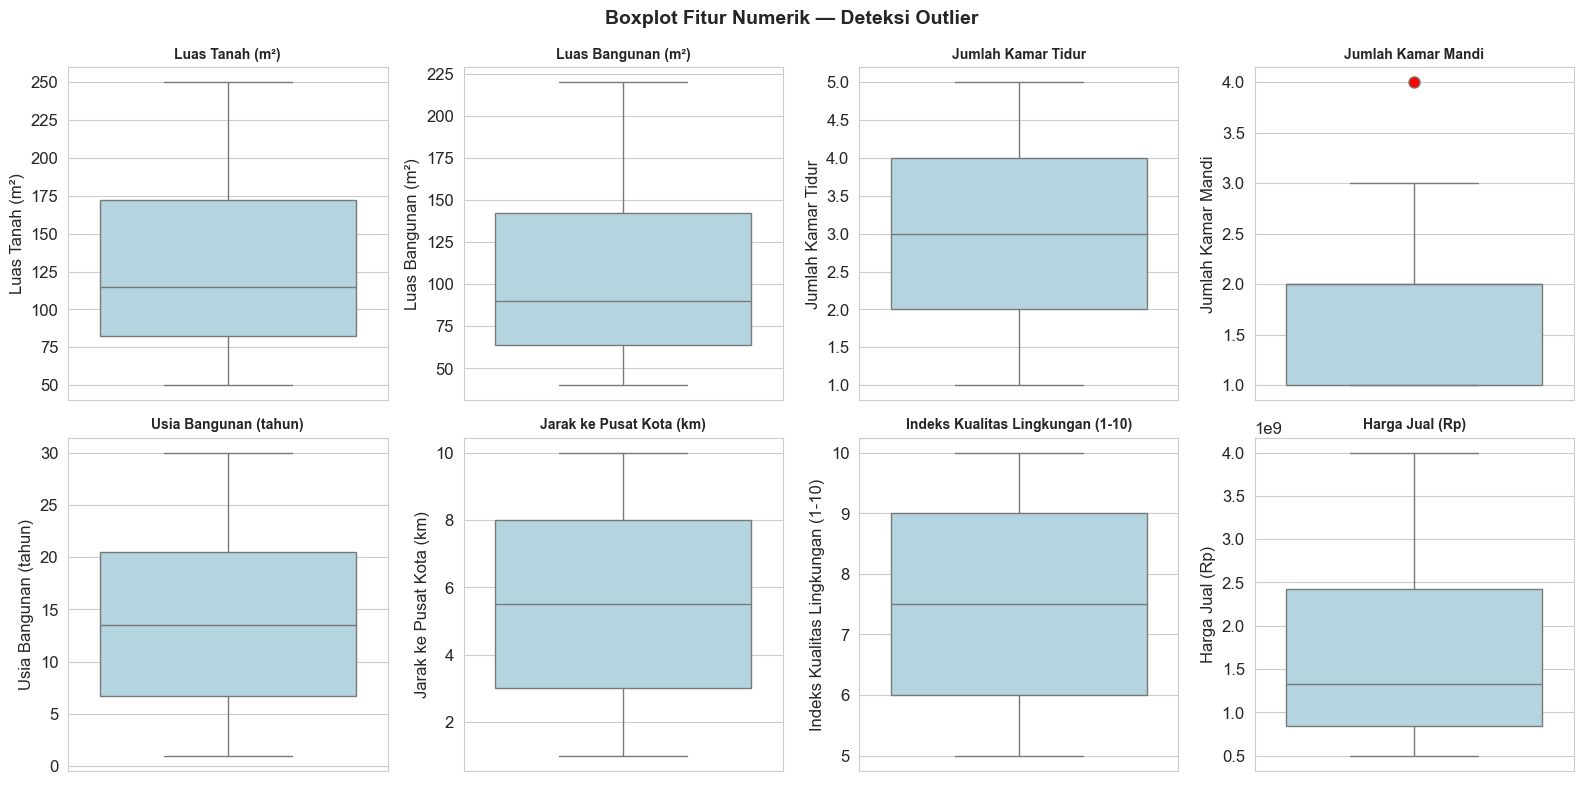

In [16]:
# Boxplot untuk semua fitur numerik (kecuali ID)
fitur_numerik = [col for col in kolom_numerik if col != 'ID']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(fitur_numerik):
    sns.boxplot(y=df[col], ax=axes[i], color='lightblue', 
                flierprops=dict(marker='o', markerfacecolor='red', markersize=8))
    axes[i].set_title(col, fontsize=10, fontweight='bold')

# Menyembunyikan subplot kosong jika ada
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplot Fitur Numerik — Deteksi Outlier', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [17]:
# Deteksi outlier menggunakan metode IQR
print('🔍 Deteksi Outlier (Metode IQR):')
for col in fitur_numerik:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    batas_bawah = Q1 - 1.5 * IQR
    batas_atas = Q3 + 1.5 * IQR
    outliers = df[(df[col] < batas_bawah) | (df[col] > batas_atas)]
    if len(outliers) > 0:
        print(f'  ⚠️ {col}: {len(outliers)} outlier terdeteksi')
    else:
        print(f'  ✅ {col}: Tidak ada outlier')

🔍 Deteksi Outlier (Metode IQR):
  ✅ Luas Tanah (m²): Tidak ada outlier
  ✅ Luas Bangunan (m²): Tidak ada outlier
  ✅ Jumlah Kamar Tidur: Tidak ada outlier
  ⚠️ Jumlah Kamar Mandi: 1 outlier terdeteksi
  ✅ Usia Bangunan (tahun): Tidak ada outlier
  ✅ Jarak ke Pusat Kota (km): Tidak ada outlier
  ✅ Indeks Kualitas Lingkungan (1-10): Tidak ada outlier
  ✅ Harga Jual (Rp): Tidak ada outlier


### ✏️ Analisis:
- Berdasarkan boxplot dan metode IQR, kita dapat mengidentifikasi outlier di masing-masing fitur
- **Penting:** Outlier belum tentu harus dihapus!
  - Jika outlier adalah **noise** (data salah input) → hapus/koreksi
  - Jika outlier adalah **informasi penting** (misalnya rumah mewah) → pertahankan
- Keputusan menghapus outlier harus berdasarkan **domain knowledge**

---
# 7. Korelasi

Melihat hubungan antar fitur numerik untuk mengidentifikasi fitur yang redundant atau memiliki hubungan kuat dengan target.

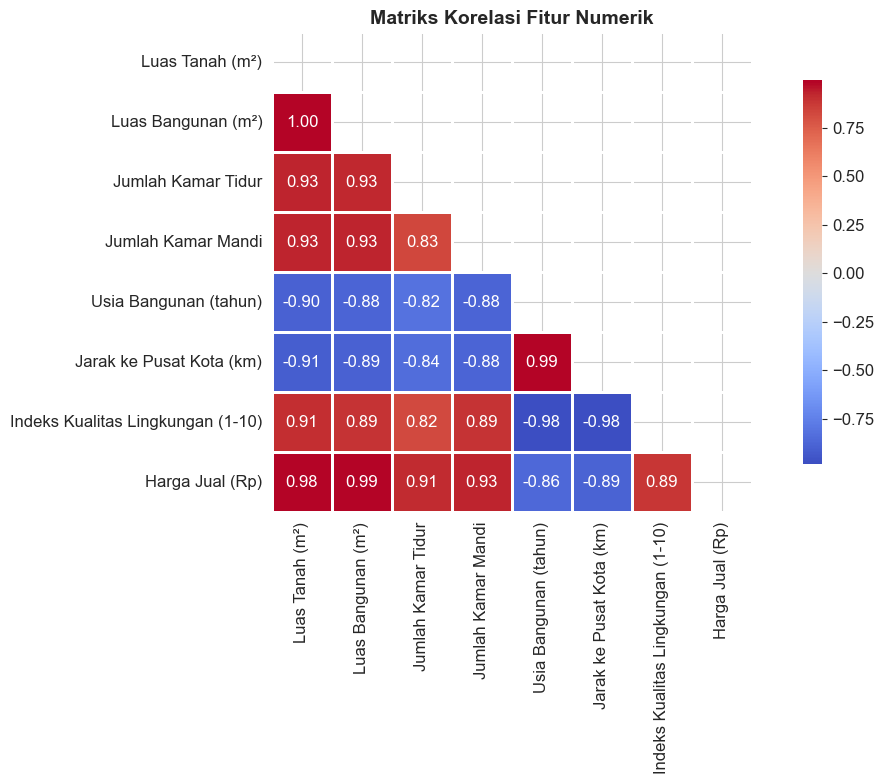

In [18]:
# Matriks korelasi
plt.figure(figsize=(12, 8))
korelasi = df[fitur_numerik].corr()
mask = np.triu(np.ones_like(korelasi, dtype=bool))  # Mask segitiga atas
sns.heatmap(korelasi, annot=True, fmt='.2f', cmap='coolwarm', 
            mask=mask, center=0, square=True,
            linewidths=1, linecolor='white',
            cbar_kws={'shrink': 0.8})
plt.title('Matriks Korelasi Fitur Numerik', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [19]:
# Korelasi setiap fitur terhadap target (Harga Jual)
print('🎯 Korelasi Fitur terhadap Harga Jual (Rp):')
target_corr = korelasi['Harga Jual (Rp)'].drop('Harga Jual (Rp)').sort_values(ascending=False)

for col, val in target_corr.items():
    strength = '🟢 Kuat' if abs(val) > 0.7 else ('🟡 Sedang' if abs(val) > 0.4 else '🔴 Lemah')
    direction = 'Positif' if val > 0 else 'Negatif'
    print(f'  {col}: {val:.3f} ({direction}, {strength})')

🎯 Korelasi Fitur terhadap Harga Jual (Rp):
  Luas Bangunan (m²): 0.990 (Positif, 🟢 Kuat)
  Luas Tanah (m²): 0.983 (Positif, 🟢 Kuat)
  Jumlah Kamar Mandi: 0.926 (Positif, 🟢 Kuat)
  Jumlah Kamar Tidur: 0.914 (Positif, 🟢 Kuat)
  Indeks Kualitas Lingkungan (1-10): 0.887 (Positif, 🟢 Kuat)
  Usia Bangunan (tahun): -0.865 (Negatif, 🟢 Kuat)
  Jarak ke Pusat Kota (km): -0.886 (Negatif, 🟢 Kuat)


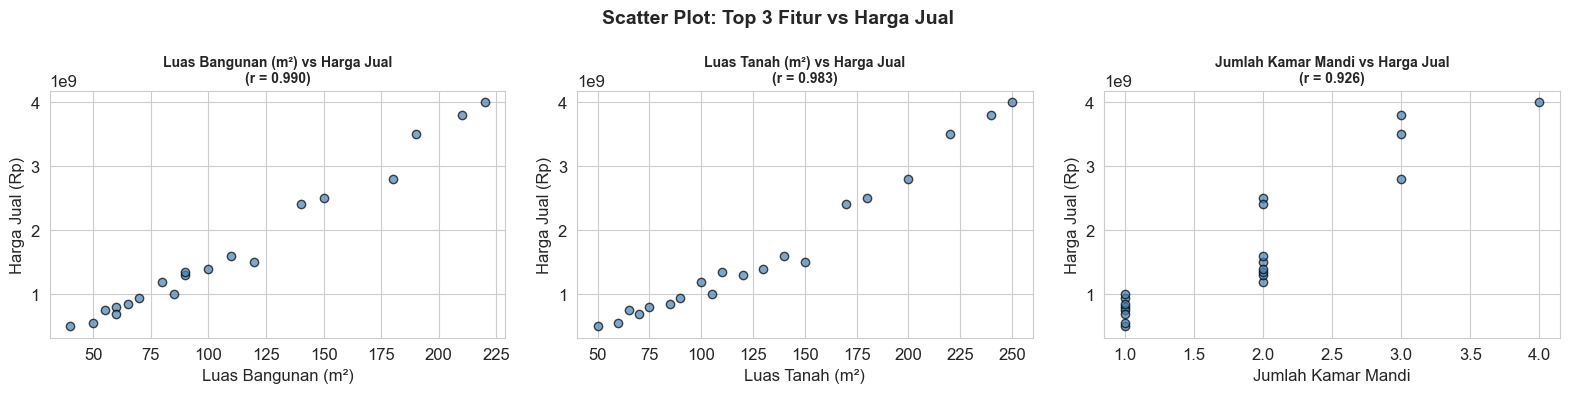

In [20]:
# Visualisasi: Scatter plot fitur teratas vs target
top_features = target_corr.head(3).index.tolist()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for i, feat in enumerate(top_features):
    axes[i].scatter(df[feat], df['Harga Jual (Rp)'], alpha=0.7, color='steelblue', edgecolors='black')
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('Harga Jual (Rp)')
    axes[i].set_title(f'{feat} vs Harga Jual\n(r = {target_corr[feat]:.3f})', fontweight='bold', fontsize=10)

plt.suptitle('Scatter Plot: Top 3 Fitur vs Harga Jual', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### ✏️ Analisis:
- Fitur dengan **korelasi kuat** terhadap Harga Jual → kandidat utama untuk model
- Fitur yang **saling berkorelasi tinggi** satu sama lain → mungkin redundant (bisa dihapus salah satu)
  - Contoh: `Luas Tanah` dan `Luas Bangunan` biasanya berkorelasi tinggi
- Fitur dengan **korelasi negatif** → hubungan terbalik (misal: semakin jauh dari kota, harga semakin murah)
- **Implikasi Feature Engineering:** Multikolinearitas perlu ditangani sebelum modeling

---
# 8. Imbalance Data

Mengecek apakah distribusi data seimbang, khususnya pada fitur kategorikal dan target (untuk klasifikasi).

In [21]:
# Distribusi Jenis Properti
print('🏠 Distribusi Jenis Properti:')
jenis_dist = df['Jenis Properti'].value_counts(normalize=True)
print(jenis_dist)
print()

🏠 Distribusi Jenis Properti:
Jenis Properti
Rumah Tapak    0.7
Apartemen      0.3
Name: proportion, dtype: float64



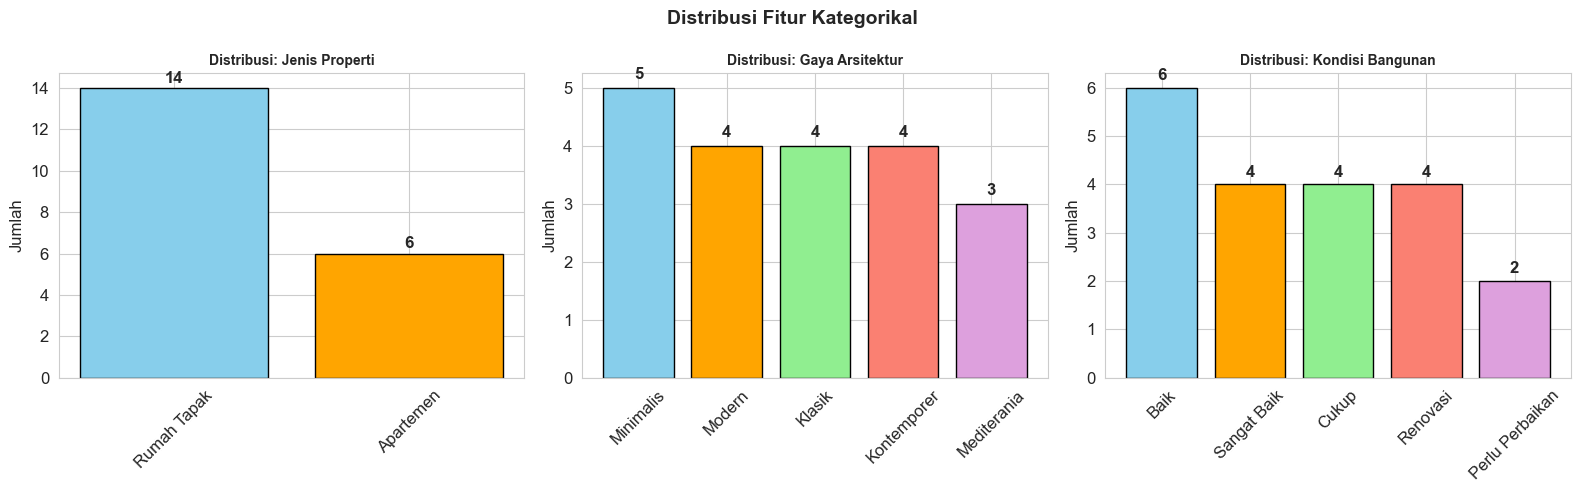

In [22]:
# Visualisasi distribusi semua kolom kategorikal
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

colors_list = ['skyblue', 'orange', 'lightgreen', 'salmon', 'plum']

for i, col in enumerate(kolom_kategorikal):
    counts = df[col].value_counts()
    bars = axes[i].bar(counts.index, counts.values, color=colors_list[:len(counts)], edgecolor='black')
    axes[i].set_title(f'Distribusi: {col}', fontweight='bold', fontsize=10)
    axes[i].set_ylabel('Jumlah')
    axes[i].tick_params(axis='x', rotation=45)
    # Menambahkan label angka di atas bar
    for bar, val in zip(bars, counts.values):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                     str(val), ha='center', va='bottom', fontweight='bold')

plt.suptitle('Distribusi Fitur Kategorikal', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [23]:
# Rata-rata harga per Jenis Properti
print('💰 Rata-rata Harga Jual per Jenis Properti:')
display(df.groupby('Jenis Properti')['Harga Jual (Rp)'].agg(['mean', 'min', 'max', 'count']))

💰 Rata-rata Harga Jual per Jenis Properti:


,mean,min,max,count
Jenis Properti,,,,
Apartemen,6.916667e+08,500000000,850000000,6
Rumah Tapak,2.092857e+09,950000000,4000000000,14


In [24]:
# Rata-rata harga per Kondisi Bangunan
print('💰 Rata-rata Harga Jual per Kondisi Bangunan:')
display(df.groupby('Kondisi Bangunan')['Harga Jual (Rp)'].agg(['mean', 'min', 'max', 'count']))

💰 Rata-rata Harga Jual per Kondisi Bangunan:


,mean,min,max,count
Kondisi Bangunan,,,,
Baik,1.783333e+09,1300000000,2500000000,6
Cukup,9.000000e+08,800000000,1000000000,4
Perlu Perbaikan,5.250000e+08,500000000,550000000,2
Renovasi,1.000000e+09,700000000,1350000000,4
Sangat Baik,3.525000e+09,2800000000,4000000000,4


### ✏️ Analisis:
- **Jenis Properti**: Rumah Tapak mendominasi (65%) dibanding Apartemen (35%) → **cukup imbalanced**
- **Gaya Arsitektur**: Distribusi relatif merata
- **Kondisi Bangunan**: Distribusi relatif merata
- **Dampak ke model:**
  - Jika digunakan untuk klasifikasi, ketidakseimbangan bisa menyebabkan bias ke kelas mayoritas
  - Solusi: oversampling, undersampling, atau class weighting

---
# 9. Data Tidak Terstruktur (Preview)

Selain data tabular, dalam dunia nyata kita juga berhadapan dengan data tidak terstruktur seperti teks, gambar, dan audio.

## Contoh Teks

In [25]:
# Contoh data teks sederhana
texts = ['produk bagus', 'jelek banget', 'lumayan', 'sangat memuaskan', 'kurang baik']

print('📝 Contoh Data Teks:')
for i, text in enumerate(texts):
    print(f'  [{i}] "{text}" — panjang: {len(text)} karakter, {len(text.split())} kata')

print('\n⚠️ Teks TIDAK bisa langsung dipakai oleh model ML!')
print('    Perlu dikonversi menjadi representasi numerik (vectorization).')

📝 Contoh Data Teks:
  [0] "produk bagus" — panjang: 12 karakter, 2 kata
  [1] "jelek banget" — panjang: 12 karakter, 2 kata
  [2] "lumayan" — panjang: 7 karakter, 1 kata
  [3] "sangat memuaskan" — panjang: 16 karakter, 2 kata
  [4] "kurang baik" — panjang: 11 karakter, 2 kata

⚠️ Teks TIDAK bisa langsung dipakai oleh model ML!
    Perlu dikonversi menjadi representasi numerik (vectorization).


In [26]:
# Simulasi sederhana: Bag of Words
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer()
X_text = vectorizer.fit_transform(texts)

print('📊 Hasil Vectorization (Bag of Words):')
bow_df = pd.DataFrame(X_text.toarray(), columns=vectorizer.get_feature_names_out())
display(bow_df)
print('\n↑ Setiap teks sudah berubah menjadi vektor numerik yang bisa diproses oleh model ML.')

📊 Hasil Vectorization (Bag of Words):


,bagus,baik,banget,jelek,kurang,lumayan,memuaskan,produk,sangat
0,1,0,0,0,0,0,0,1,0
1,0,0,1,1,0,0,0,0,0
2,0,0,0,0,0,1,0,0,0
3,0,0,0,0,0,0,1,0,1
4,0,1,0,0,1,0,0,0,0



↑ Setiap teks sudah berubah menjadi vektor numerik yang bisa diproses oleh model ML.


### ✏️ Analisis:
- Teks **tidak bisa langsung** digunakan oleh model machine learning
- Perlu proses **vectorization** (Bag of Words, TF-IDF, Word2Vec, dll.)
- Feature engineering pada teks termasuk: tokenization, stopword removal, stemming/lemmatization

---
# 10. Insight → Feature Engineering

Berdasarkan seluruh analisis di atas, berikut adalah pemetaan temuan data dan implikasi terhadap rekayasa fitur (feature engineering):

| No | Temuan Data | Implikasi Feature Engineering | Contoh Tindakan |
|:--:|:-----------|:----------------------------|:---------------|
| 1 | Data skewed (Harga Jual) | Transformasi distribusi | Transformasi log, sqrt, Box-Cox |
| 2 | Missing value | Imputasi | Mean/Median/Mode, KNN Imputer |
| 3 | Fitur kategorikal | Encoding | One-Hot, Label, Target Encoding |
| 4 | Fitur saling berkorelasi tinggi | Reduksi dimensi | PCA, drop fitur redundant |
| 5 | Outlier terdeteksi | Penanganan pencilan | Clipping, IQR, Z-Score |
| 6 | Data teks | Vectorization | BoW, TF-IDF, Word Embedding |
| 7 | Data gambar | Feature extraction | CNN, HOG, SIFT |
| 8 | Imbalance data | Resampling | SMOTE, Undersampling |

In [27]:
# Rangkuman temuan pada dataset kita
print('=' * 60)
print('📋 RANGKUMAN TEMUAN DATA — dataset_harga_rumah.csv')
print('=' * 60)
print(f'  📐 Jumlah data       : {df.shape[0]} baris, {df.shape[1]} kolom')
print(f'  📊 Fitur numerik     : {len(kolom_numerik)} kolom')
print(f'  🏷️ Fitur kategorikal : {len(kolom_kategorikal)} kolom')
print(f'  ❓ Missing values    : {df.isnull().sum().sum()} (total)')
print(f'  🎯 Target variable   : Harga Jual (Rp)')
print(f'  📊 Range harga       : Rp {df["Harga Jual (Rp)"].min():,.0f} - Rp {df["Harga Jual (Rp)"].max():,.0f}')
print('=' * 60)

📋 RANGKUMAN TEMUAN DATA — dataset_harga_rumah.csv
  📐 Jumlah data       : 20 baris, 12 kolom
  📊 Fitur numerik     : 9 kolom
  🏷️ Fitur kategorikal : 3 kolom
  ❓ Missing values    : 0 (total)
  🎯 Target variable   : Harga Jual (Rp)
  📊 Range harga       : Rp 500,000,000 - Rp 4,000,000,000


---
# 11. Latihan

## Tugas:
1. **Identifikasi 3 masalah utama** pada dataset ini
2. **Tentukan solusi preprocessing** yang tepat untuk masing-masing masalah
3. **Jelaskan dampaknya** ke model jika masalah tersebut tidak ditangani

### Panduan:
Gunakan sel kode di bawah ini untuk menjawab. Tuliskan analisis anda dalam bentuk print statement atau markdown.

In [28]:
# ============================================
# LATIHAN: Tulis jawaban anda di sini
# ============================================

# Masalah 1: ...
# Solusi    : ...
# Dampak    : ...

# Masalah 2: ...
# Solusi    : ...
# Dampak    : ...

# Masalah 3: ...
# Solusi    : ...
# Dampak    : ...

---
# 12. Refleksi

Jawab pertanyaan-pertanyaan berikut berdasarkan analisis yang telah dilakukan:

1. **Apa masalah terbesar pada data ini?**
   - *(Tulis jawaban anda)*

2. **Apa risiko jika langsung melakukan modeling tanpa EDA dan preprocessing?**
   - *(Tulis jawaban anda)*

3. **Apa langkah selanjutnya sebelum training?**
   - *(Tulis jawaban anda)*

---
# ⚠️ Catatan Penting

**Kesalahan umum yang harus dihindari:**

| No | Kesalahan | Dampak |
|:--:|:---------|:------|
| 1 | ❌ Langsung training tanpa EDA | Model tidak optimal, bisa gagal |
| 2 | ❌ Menghapus outlier tanpa analisis | Kehilangan informasi penting |
| 3 | ❌ Mengabaikan imbalance | Model bias terhadap kelas mayoritas |
| 4 | ❌ Tidak cek data leakage | Akurasi tinggi palsu (overfitting) |
| 5 | ❌ Tidak memahami domain data | Feature engineering yang salah |

---
# 🚀 Kesimpulan

Tujuan utama dari pemahaman data:

> **Mengubah data menjadi representasi yang siap untuk model.**

### Ukuran Keberhasilan:
- ❌ Jika **hanya menghasilkan grafik** → belum cukup
- ✅ Jika **menghasilkan keputusan** (apa yang perlu diubah, dibuang, atau ditambahkan) → **berhasil!**

### Langkah Selanjutnya → Feature Engineering:
1. Encoding variabel kategorikal
2. Transformasi fitur skewed
3. Handling outlier
4. Feature selection
5. Feature creation (membuat fitur baru)

---
*Notebook v3 — Mata Kuliah Rekayasa Fitur, Universitas Komputer Indonesia (UNIKOM)*